<a href="https://colab.research.google.com/github/hsmu-jeongeun/health-infomatics/blob/main/13_Wearable_Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 13주차 실습: 웨어러블과 시계열 데이터

## 학습 목표
- 연속혈당측정기(CGM) 시계열 데이터의 특성을 이해할 수 있다
- Pandas로 결측치를 보간(Interpolation)하여 처리할 수 있다
- 시계열 데이터에서 피크(최고값) 시간대를 탐색할 수 있다

---

## 오늘의 핵심 개념: 데이터마이닝과 웨어러블

> **비유:** CGM(연속혈당측정기)은 15분마다 자동으로 혈당을 측정. 하루 24시간에 96개의 데이터 포인트 생성.
> 가끔 센서 오류로 값이 빠지는 경우는 어떻게 처리해야 할까? 보간(Interpolation) 필요

### 데이터마이닝이란?
- 대용량 데이터에서 유용한 패턴·지식을 추출하는 기술
- **시계열 마이닝:** 혈당 패턴, 심박 변이도, 수면 패턴 분석
- **연관규칙 마이닝:** '고혈당 + 수면 부족 → 다음날 인슐린 저항성 증가' 같은 패턴 발견

### 웨어러블 의료 기기
- **CGM(연속혈당측정기):** 당뇨 환자의 혈당을 15분 간격으로 자동 측정
- **스마트워치:** 심박수, 산소포화도, 심전도(ECG) 측정 가능
- **스마트 패치:** 체온·혈압·호흡수 연속 모니터링

### 결측치 처리 방법
| 방법 | 설명 | 적합한 경우 |
|------|------|------------|
| 제거 | 해당 행 삭제 | 결측치 < 5% |
| 평균 대체 | 전체 평균으로 채움 | 시계열 외 데이터 |
| 보간 | 앞뒤 값으로 추정 | **시계열 데이터** |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from datetime import datetime, timedelta

matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료!')

라이브러리 로드 완료!


## Step 1. 1일 CGM 데이터 생성

- 15분 간격 = 하루 96개 측정값

In [ ]:
np.random.seed(42)

# 날짜/시간 인덱스 생성 (15분 간격)
start = datetime(2026, 1, 15, 0, 0, 0)
times = [start + timedelta(minutes=15*i) for i in range(96)]
hours = np.array([t.hour + t.minute/60 for t in times])

# 현실적인 혈당 패턴 시뮬레이션
# 기저 혈당: 공복 ~90, 식후 급등
def simulate_glucose(hours, seed=42):
    np.random.seed(seed)
    glucose = np.ones(len(hours)) * 90.0

    # 아침 식사 (7~9시): 7:30에 피크
    for i, h in enumerate(hours):
        if 7.0 <= h <= 10.0:
            glucose[i] += 80 * np.exp(-((h - 8.0)**2) / (2 * 0.5**2))
        # 점심 (12~14시): 12:30에 피크
        if 11.5 <= h <= 14.5:
            glucose[i] += 95 * np.exp(-((h - 12.5)**2) / (2 * 0.4**2))
        # 저녁 (18~20시): 18:30에 피크
        if 17.5 <= h <= 21.0:
            glucose[i] += 90 * np.exp(-((h - 18.5)**2) / (2 * 0.5**2))
        # 야식 (22시): 작은 피크
        if 21.5 <= h <= 23.5:
            glucose[i] += 45 * np.exp(-((h - 22.0)**2) / (2 * 0.3**2))

    noise = np.random.normal(0, 4, len(hours))
    return np.clip(glucose + noise, 60, 400)

glucose_clean = simulate_glucose(hours)

print(f'생성된 CGM 데이터: {len(glucose_clean)}개 측정점')
print(f'측정 간격: 15분  |  총 시간: 24시간')
print(f'혈당 범위: {glucose_clean.min():.1f} ~ {glucose_clean.max():.1f} mg/dL')

생성된 CGM 데이터: 96개 측정점
측정 간격: 15분  |  총 시간: 24시간
혈당 범위: 82.3 ~ 186.3 mg/dL


## Step 2. 결측치 임의 생성

- 센서 오류 시뮬레이션

In [ ]:
# 결측치 생성 (약 10% — 센서 오류/수면 중 기기 분리 등)
np.random.seed(7)
glucose_missing = glucose_clean.copy().astype(float)

# 랜덤 위치에 결측치 삽입
missing_idx = np.random.choice(range(5, 91), size=12, replace=False)
glucose_missing[missing_idx] = np.nan

# 연속 결측 구간 (수면 중 기기 분리 시뮬레이션: 2~5시)
sleep_miss = [i for i in range(len(hours)) if 2.0 <= hours[i] <= 4.5]
glucose_missing[sleep_miss[:5]] = np.nan

missing_count = np.isnan(glucose_missing).sum()
print(f'총 결측치: {missing_count}개 ({missing_count/len(glucose_missing)*100:.1f}%)')
print(f'결측 위치 (인덱스): {np.where(np.isnan(glucose_missing))[0].tolist()}')

총 결측치: 17개 (17.7%)
결측 위치 (인덱스): [8, 9, 10, 11, 12, 16, 17, 18, 20, 22, 25, 38, 45, 50, 79, 87, 90]


## Step 3. 보간으로 결측치 처리

In [ ]:
# Pandas Series로 변환
ts = pd.Series(glucose_missing, index=times)

# =====================
# 수정해 보세요!
# =====================
interp_method = 'cubic'   # 'linear', 'cubic', 'nearest' 중 선택
# =====================

# 보간 적용
ts_interpolated = ts.interpolate(method=interp_method)

print(f'보간 방법: {interp_method}')
print(f'보간 전 결측치: {ts.isna().sum()}개')
print(f'보간 후 결측치: {ts_interpolated.isna().sum()}개')

보간 방법: cubic
보간 전 결측치: 17개
보간 후 결측치: 0개


In [ ]:
ts_interpolated.info()

<class 'pandas.Series'>
DatetimeIndex: 96 entries, 2026-01-15 00:00:00 to 2026-01-15 23:45:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
96 non-null     float64
dtypes: float64(1)
memory usage: 1.5 KB


In [ ]:
filtered_data = ts_interpolated[ts_interpolated > 100.0]
filtered_data

2026-01-15 07:15:00    114.805422
2026-01-15 07:30:00    136.115626
2026-01-15 07:45:00    168.008865
2026-01-15 08:00:00    169.946011
2026-01-15 08:15:00    156.368908
2026-01-15 08:30:00    141.812632
2026-01-15 08:45:00    111.088823
2026-01-15 09:00:00    101.662277
2026-01-15 11:45:00    110.608543
2026-01-15 12:00:00    134.868643
2026-01-15 12:15:00    161.092708
2026-01-15 12:30:00    176.525037
2026-01-15 12:45:00    166.604539
2026-01-15 13:00:00    130.786481
2026-01-15 13:15:00    108.826759
2026-01-15 17:30:00    103.625758
2026-01-15 17:45:00    125.370868
2026-01-15 18:00:00    144.444455
2026-01-15 18:15:00    175.683296
2026-01-15 18:30:00    169.521020
2026-01-15 18:45:00    172.712331
2026-01-15 19:00:00    144.935948
2026-01-15 19:15:00    118.022693
2026-01-15 19:30:00    102.547219
2026-01-15 21:30:00    104.882458
2026-01-15 21:45:00    124.452453
2026-01-15 22:00:00    132.880959
2026-01-15 22:15:00    123.852242
2026-01-15 22:30:00    109.508690
dtype: float64

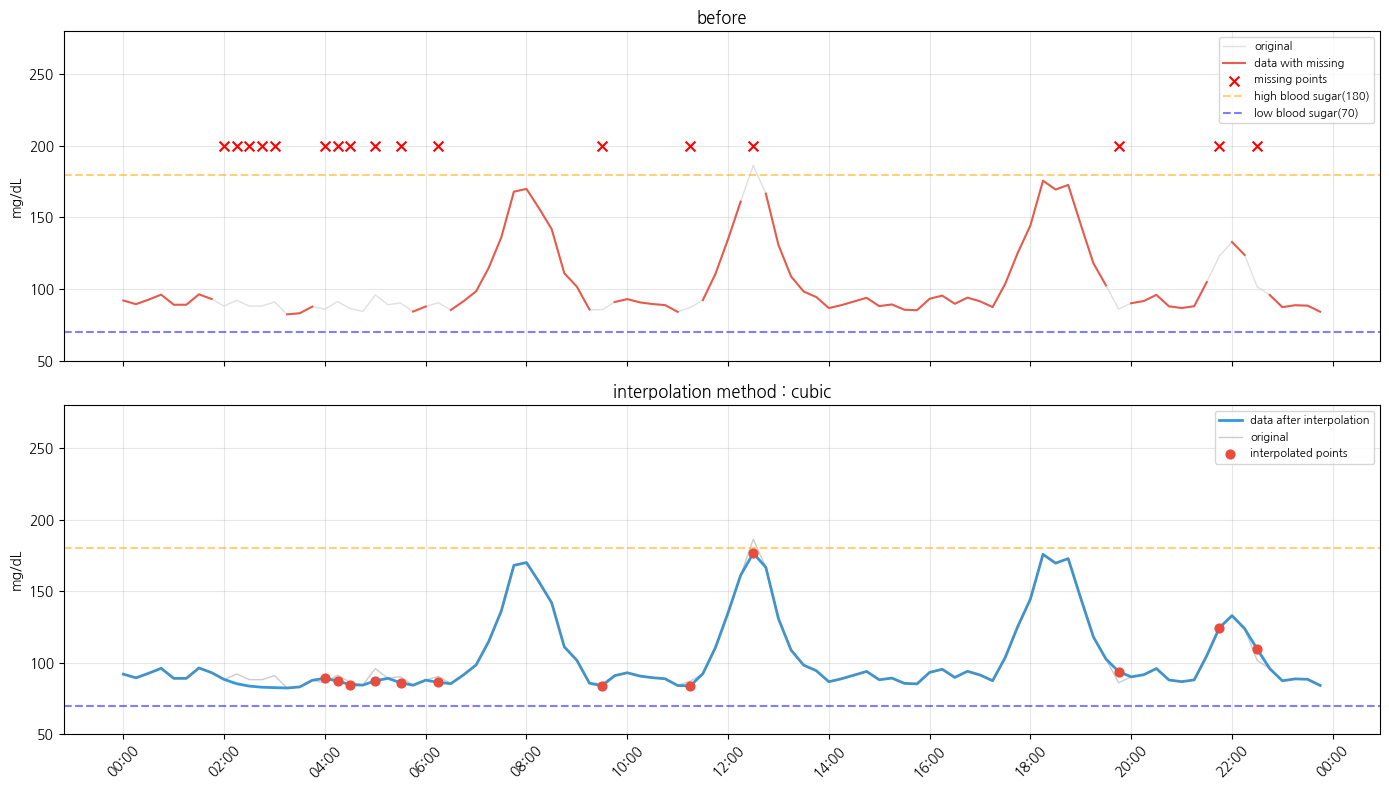

In [ ]:
# 시각화: 결측 → 보간 비교
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 결측 데이터
axes[0].plot(times, glucose_clean, color='lightgray', linewidth=1, label='original', alpha=0.7)
axes[0].plot(times, glucose_missing, color='#e74c3c', linewidth=1.5, label='data with missing', alpha=0.9)
axes[0].scatter([times[i] for i in np.where(np.isnan(glucose_missing))[0]],
                [200]*missing_count, color='red', zorder=5, marker='x', s=50, label='missing points')
axes[0].set_title('before', fontsize=12)
axes[0].set_ylabel('mg/dL')
axes[0].axhline(y=180, color='orange', linestyle='--', alpha=0.5, label='high blood sugar(180)')
axes[0].axhline(y=70,  color='blue',   linestyle='--', alpha=0.5, label='low blood sugar(70)')
axes[0].legend(fontsize=8)
axes[0].set_ylim(50, 280)

# 보간 후
axes[1].plot(times, ts_interpolated.values, color='#3498db', linewidth=2, label='data after interpolation')
axes[1].plot(times, glucose_clean,          color='gray',    linewidth=1, alpha=0.4, label='original')
axes[1].scatter([times[i] for i in missing_idx], ts_interpolated.values[missing_idx],
                color='#e74c3c', zorder=5, s=40, label='interpolated points')
axes[1].set_title(f'interpolation method : {interp_method}', fontsize=12)
axes[1].set_ylabel('mg/dL')
axes[1].axhline(y=180, color='orange', linestyle='--', alpha=0.5)
axes[1].axhline(y=70,  color='blue',   linestyle='--', alpha=0.5)
axes[1].legend(fontsize=8)
axes[1].set_ylim(50, 280)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 4. 혈당 최고치 시간대 탐색

peak time in day :  12시 30분
peak value : 176.5 mg/dL
peak hour : 12

=== average blood sugar per hour ===


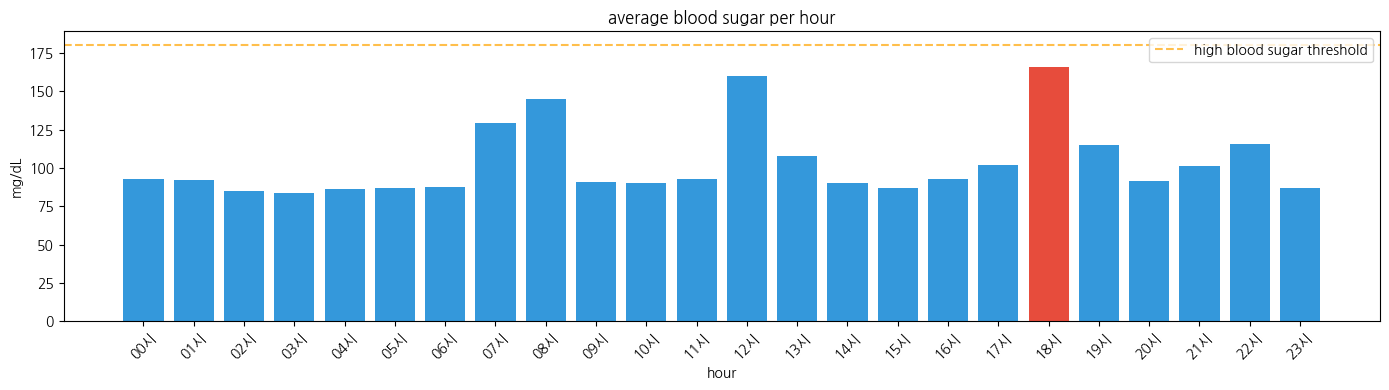

In [ ]:
# 보간 후 데이터에서 피크 시간대 탐색
peak_idx  = ts_interpolated.values.argmax()
peak_time = times[peak_idx]
peak_val  = ts_interpolated.values[peak_idx]

print(f'peak time in day :  {peak_time.strftime("%H시 %M분")}')
print(f'peak value : {peak_val:.1f} mg/dL')
print(f'peak hour : {peak_time.hour}')

# 식사 후 혈당 상승 패턴 분석
print('\n=== average blood sugar per hour ===')
df_cgm = pd.DataFrame({'시간': times, '혈당': ts_interpolated.values})
df_cgm['시간대'] = df_cgm['시간'].apply(lambda t: f'{t.hour:02d}시')
hourly_mean = df_cgm.groupby('시간대')['혈당'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#e74c3c' if v == hourly_mean.max() else '#3498db' for v in hourly_mean.values]
ax.bar(hourly_mean.index, hourly_mean.values, color=colors)
ax.set_title('average blood sugar per hour', fontsize=12)
ax.set_xlabel('hour')
ax.set_ylabel('mg/dL')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=180, color='orange', linestyle='--', alpha=0.7, label='high blood sugar threshold')
ax.legend()
plt.tight_layout()
plt.show()

---

## Canvas 퀴즈 안내

아래 코드 셀을 실행하여 나온 **숫자**를 Canvas 퀴즈의 정답으로 제출하세요.

**문제:** bicubic으로 보간 처리 후, 하루 중 혈당이 가장 높은 시간대(시)는 몇 시?

In [ ]:
# [실습] 아래 코드를 실행하여 나온 결과를 Canvas 퀴즈의 정답으로 제출
canvas_answer = peak_time.hour
print(f'Answer: {canvas_answer}')